Solve
$$
\mathbf{A} \mathbf{x} = \mathbf{b}
$$
by minimizing the function
$$
f(\mathbf{x}) = \frac{1}{2} \| \mathbf{A} \mathbf{x} - \mathbf{b} \|^{2}_{2}.
$$

We will have $\mathbf{A} \in \mathbb{R}^{2 \times 2}$, $\mathbf{x} \in \mathbb{R}^2$, and $\mathbf{b} \in \mathbb{R}^2$.
Thus, treat $\mathbf{x}$ as parameters of an `nn.Module` and use SGD to minimize the function $f$.

In [ ]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

import gradient_flow_optimizer

torch.manual_seed(0)

cond = 10.0
A = torch.tensor([[cond, 0.0], [0.0, 1.0]])
b = torch.tensor([1.0, 1.0])
# compute the analytic solution
x_star = torch.linalg.solve(A, b)

x0 = torch.tensor([[2.0, 4.0]]).T

class QuadraticModel(nn.Module):
    def __init__(self, A, x0):
        super(QuadraticModel, self).__init__()
        self.A = A
        self.x = nn.Parameter(x0.clone(), requires_grad=True)

    def forward(self):
        return torch.matmul(A, self.x)

In [3]:

# optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
# x_history = []

# set up a collection of optimizers that we will iterate through. Each one will store it's own results
optimizer_names = {'sgd', 'gradient_flow', 'sindy_flow_tr', 'sindy_flow'}
optimizers = {}
for opt_name in optimizer_names:
    optimizers[opt_name] = {
        'model': QuadraticModel(A, x0),
        'optimizer': None,
        'losses': [],
        'param_history': []
    }
# keep order consistent with the order of the names above
sorted_opt_names = sorted(optimizers.keys())
optimizers = {name: optimizers[name] for name in sorted_opt_names}

epochs = 150
lr = 10**-2
history_size = 10
retrain_interval = 15
sindy_kwargs = {'poly_order': 1, 'include_bias': True, 'rcond': None}
# gradient_flow_optimizer.sindy_tools.create_sindy_library()
optimizers['sgd']['optimizer'] = torch.optim.SGD(optimizers['sgd']['model'].parameters(), lr=lr)
optimizers['gradient_flow']['optimizer'] = gradient_flow_optimizer.GradientFlow(
                                            optimizers['gradient_flow']['model'].parameters(),
                                            dt=lr)
optimizers['sindy_flow_tr']['optimizer'] = gradient_flow_optimizer.SINDyFlowTrustRegion(
                                            optimizers['sindy_flow_tr']['model'].parameters(),
                                            backup_optimizer=torch.optim.SGD(
                                                optimizers['sindy_flow_tr']['model'].parameters(),
                                                lr=lr
                                            ),
                                            dt=lr,
                                            history_size=history_size,
                                            sindy_kwargs=sindy_kwargs)
optimizers['sindy_flow']['optimizer'] = gradient_flow_optimizer.SINDyFlow(
                                            optimizers['sindy_flow']['model'].parameters(),
                                            backup_optimizer=torch.optim.SGD(
                                                optimizers['sindy_flow']['model'].parameters(),
                                                lr=lr
                                            ),
                                            dt=lr,
                                            history_size=history_size,
                                            retrain_interval=retrain_interval,
                                            sindy_kwargs=sindy_kwargs)


# append initial x0 to all parameter histories
for opt_name, opt_data in optimizers.items():
    opt_data['param_history'].append(opt_data['model'].x.detach().clone())

# epochs = 100
# for epoch in range(epochs):
#     optimizer.zero_grad()
#     loss = torch.norm(model.forward() - b) ** 2
#     x_history.append(model.x.detach())
#     loss.backward()
#     optimizer.step()

# We need to use closure, so get the closure for a given optimizer


def create_closure(model, optimizer):
    def closure():
        optimizer.zero_grad()
        loss = 0.5*torch.norm(model.forward() - b) ** 2
        loss.backward()
        return loss
    return closure


for epoch in range(epochs):
    for opt_name, opt_data in optimizers.items():
        model = opt_data['model']
        optimizer = opt_data['optimizer']
        closure_fn = create_closure(model, optimizer)

        loss = optimizer.step(closure_fn)

        opt_data['losses'].append(loss.item())
        opt_data['param_history'].append(model.x.detach().clone())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}")

for opt_name, opt_data in optimizers.items():
    # get number of evals, and record them. We will put them in legend
    if hasattr(opt_data['optimizer'], 'state'):
        func_evals = opt_data['optimizer'].state.get('func_evals', None)
        if func_evals is not None:
            opt_data['func_evals'] = func_evals
        else:
            opt_data['func_evals'] = epochs
    else:
        opt_data['func_evals'] = epochs

Epoch 0
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\grant\anaconda3\envs\streaming-sindy\Lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\grant\AppData\Local\Temp\ipykernel_30188\3080711222.py", line 80, in <module>
    loss = optimizer.step(closure_fn)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grant\anaconda3\envs\streaming-sindy\Lib\site-packages\torch\optim\optimizer.py", line 487, in wrapper
    out = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grant\Documents\research\learning_gradient_flow\gradient_flow_optimizer.py", line 433, in step
    pred = self.build_sindy_model(**self.sindy_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\grant\Documents\research\learning_gradient_flow\gradient_flow_optimizer.py", line 543, in build_sindy_model
    ode_lib = ps.WeakPDELibrary(
              ^^^^^^^^^^^^^^^^^^
  File "c:\Us

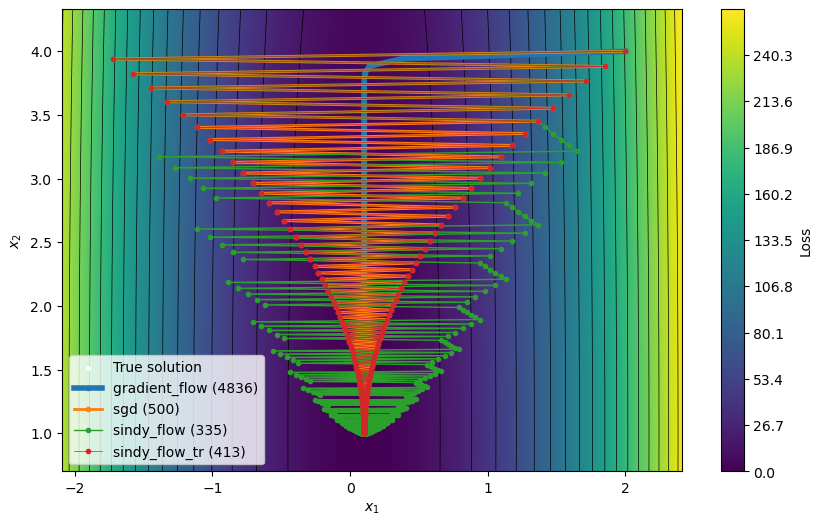

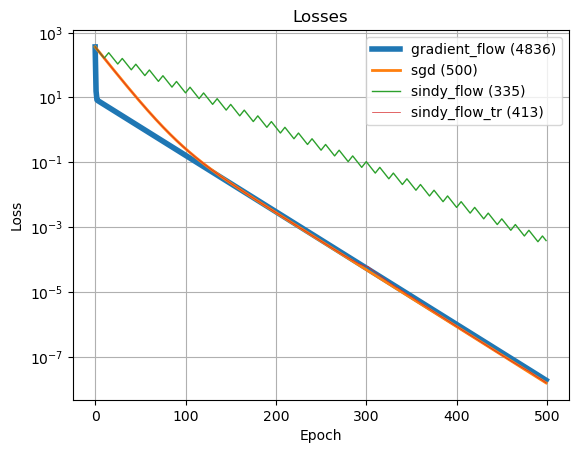

In [ ]:

# Now construct a contour plot of the loss function
# get the xbounds by looking at the x_star and the initial x0
# x_min = min(x_star[0].item(), x0[0].item())
# x_max = max(x_star[0].item(), x0[0].item())
# y_min = min(x_star[1].item(), x0[1].item())
# y_max = max(x_star[1].item(), x0[1].item())
# get x from all trajectories
x_min = float('inf')
x_max = float('-inf')
y_min = float('inf')
y_max = float('-inf')
for opt_name, opt_data in optimizers.items():
    param_history = torch.stack(opt_data['param_history']).squeeze()
    x_min = min(x_min, param_history[:, 0].min().item())
    x_max = max(x_max, param_history[:, 0].max().item())
    y_min = min(y_min, param_history[:, 1].min().item())
    y_max = max(y_max, param_history[:, 1].max().item())

# and x_star
x_min = min(x_min, x_star[0].item())
x_max = max(x_max, x_star[0].item())
y_min = min(y_min, x_star[1].item())
y_max = max(y_max, x_star[1].item())

# add some padding based on the total size
x_min -= 0.1 * (x_max - x_min)
x_max += 0.1 * (x_max - x_min)
y_min -= 0.1 * (y_max - y_min)
y_max += 0.1 * (y_max - y_min)

x1 = torch.linspace(x_min, x_max, 100)
x2 = torch.linspace(y_min, y_max, 100)


X1, X2 = torch.meshgrid(x1, x2)
X = torch.stack([X1.flatten(), X2.flatten()]).T
# Evaluate by being smart with linear algebra, we can do A @ X in one go
Y = torch.matmul(A, X.T).T
Z = 0.5 * torch.norm(Y - b, dim=1) ** 2
Z = Z.reshape(X1.shape)

plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, Z, levels=1000, cmap='viridis')
# show contour lines
plt.contour(X1, X2, Z, levels=20, colors='black', linewidths=0.5)
plt.scatter(x_star[0], x_star[1], color='white', marker='.', s=10, label='True solution', linewidths=2)

# now show paths
lw = 4
for opt_name, opt_data in optimizers.items():
    param_history = torch.stack(opt_data['param_history']).squeeze()
    lbl = f"{opt_name} ({opt_data['func_evals']})"
    plt.plot(param_history[:, 0], param_history[:, 1], '.-', label=lbl, linewidth=lw)
    lw *= 0.5

# colorbar for contour
plt.colorbar(contour, label='Loss')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

plt.legend()
# save
plt.savefig('quadratic_contour.png', dpi=300, bbox_inches='tight')

# plot losses
plt.figure()
plt.title('Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
lw = 4
for opt_name, opt_data in optimizers.items():
    lbl = f"{opt_name} ({opt_data['func_evals']})"
    plt.semilogy(opt_data['losses'], label=lbl, linewidth=lw)
    lw *= 0.5
plt.legend()

plt.grid()
plt.savefig('quadratic_losses.png', dpi=300, bbox_inches='tight')